In [4]:
import os
import numpy as np
import seaborn as sns
import pandas as pd
from contrastive.utils.models_database import generate_bdd_models
import matplotlib.pyplot as plt

In [27]:
## Automated but complicated ...
models_path = "/neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/"
list_dir = os.listdir(models_path)
paths = [models_path + elem for elem in list_dir]

bdd_models = []

generate_bdd_models(paths, bdd_models=bdd_models, visited=[], dataset='cingulate_ACCpatterns_1')

Start 16 0
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/baby_size_0
End model 15 1
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/ACC_adult_size_1
End model 14 2
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/ACC_adult_size_4
End model 13 3
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/baby_size_4
End model 12 4
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/baby_size_6
End model 11 5
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/baby_size_7
End model 10 6
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/ACC_adult_size_2
End model 9 7
Treating /neurospin/dico/jlaval/Runs/01_deep_supervised/Program/Output/comparison_HCP_full/baby_size_5
End model 8 8
Treating /neurospin/dico/jlaval/

In [5]:
##handmade AUC plots

#copy AUC values of the different models

ACC_adult_size = [0.726, 0.640, 0.681, 0.710, 0.750, 0.686, 0.699, 0.697]
ACC_baby_size = [0.631, 0.675, 0.499, 0.558, 0.677, 0.619, 0.492, 0.550]
Preterm_baby_size = [0.525, 0.587, 0.698, 0.619, 0.660, 0.591, 0.653, 0.671]
ACC_resize = [0.756, 0.707, 0.730, 0.754, 0.732, 0.715, 0.715, 0.719]
Preterm_resize = [0.533, 0.641, 0.512, 0.517, 0.501, 0.453, 0.479, 0.588]

dict_plot = {"ACC Adult Size": ACC_adult_size,
             "ACC Baby Size": ACC_baby_size,
             "Preterm Baby Size": Preterm_baby_size,
             "ACC Resize": ACC_resize,
             "Preterm Resize": Preterm_resize}



In [6]:
#reformat dictionnary into dataframe for seaborn
df = pd.DataFrame({'Model': [], 'AUC': []})
for model in dict_plot.keys():
    list_values = dict_plot[model]
    for value in list_values:
        new_row = {'Model': model, 'AUC': value}
        df = df.append(new_row, ignore_index=True)

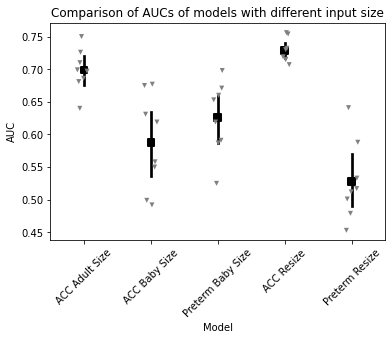

In [8]:
sns.pointplot(data=df, x='Model', y='AUC', palette=['black'], markers='s').set(title='Comparison of AUCs of models with different input size')
sns.stripplot(data=df, x='Model', y='AUC', palette=['grey'], marker='v')
plt.xticks(rotation=30)
save_dir = '/home/jl274628/Images/'
plt.savefig(save_dir+'Comparison_AUCs_Resize.png', facecolor='white')

In [71]:
from scipy.ndimage import zoom

input_shape = np.array([21,48,49])
a = np.ones((17,40,38))
ratios = input_shape/np.array(a.shape)
b = zoom(a, ratios)
b.shape

(21, 48, 49)